# Pseudotime Metrics Visualization

This section visualizes the main pseudotime evaluation metrics for each embedding layer.

All plots are minimal, clear, and in English.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # Aggiungi la root del progetto
from trajectory_analysis.plot_pseudotime_metrics import (
    load_trajectory_metrics,
    plot_pseudotime_correlation,
    plot_neighborhood_overlap,
    plot_global_geometry_alignment,
    )
import pandas as pd
results_csv = '../data/pseudotime_results/inner_ear_development_tahoe_embeddings_results.csv'
results = load_trajectory_metrics(results_csv)

In [2]:
import scanpy as sc

sc.settings.n_jobs = 1


Misura la correlazione di Spearman tra il pseudotempo di riferimento (calcolato su PCA dei geni variabili) e il pseudotempo ottenuto dall’embedding testato. Valuta quanto bene l’ordine temporale delle cellule è preservato nell’embedding.

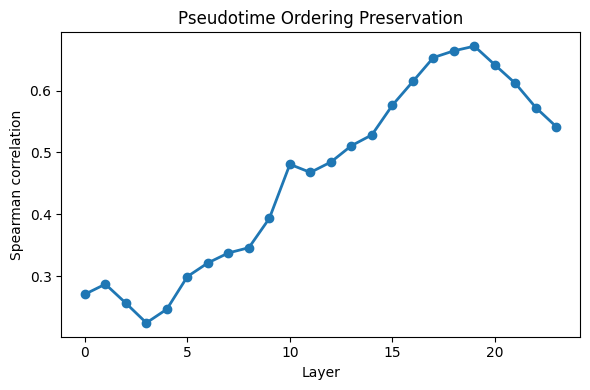

In [3]:
plot_pseudotime_correlation(results)

Calcola la sovrapposizione media tra i vicini più prossimi (k-NN) nel riferimento e nell’embedding. Indica quanto le relazioni locali tra cellule (vicinato) sono mantenute nell’embedding rispetto al riferimento.

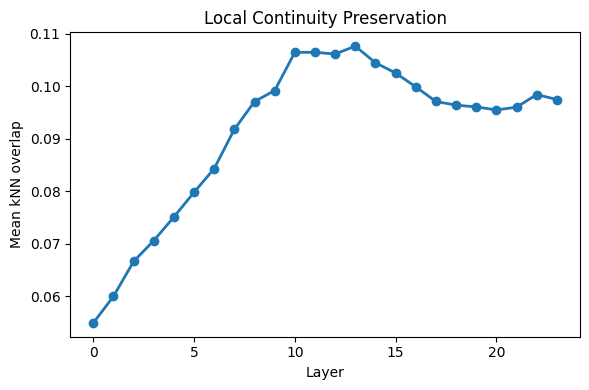

In [4]:
# Plot neighborhood overlap (local continuity)
plot_neighborhood_overlap(results)

Misura la correlazione tra la differenza di pseudotempo (delta-time) e la distanza euclidea nell’embedding, su coppie casuali di cellule. Valuta se le distanze nell’embedding riflettono la progressione temporale globale.

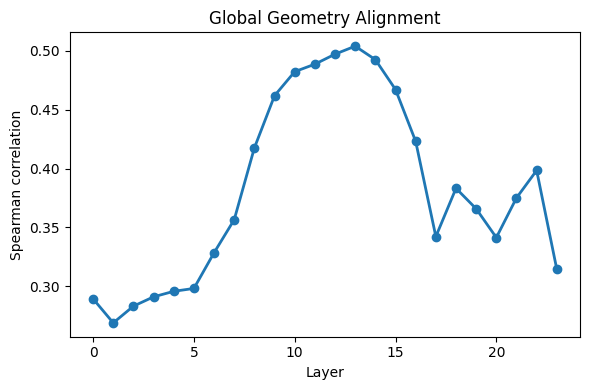

In [5]:
plot_global_geometry_alignment(results)

In [6]:
import scanpy as sc

adata = sc.read_h5ad('/data2/home/vcivale/scfm-layer-analysis-refactored/data/embeddings/inner_ear_development_tahoe_embeddings.h5ad')

Miglior layer intermedio scelto: X_layer_19


/data2/home/vcivale/scfm-layer-analysis-refactored/.venv/lib64/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 2048 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/data2/home/vcivale/scfm-layer-analysis-refactored/.venv/lib64/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/data2/home/vcivale/scfm-layer-analysis-refactored/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data2/home/vcivale/scfm-layer-analysis-refactored/.

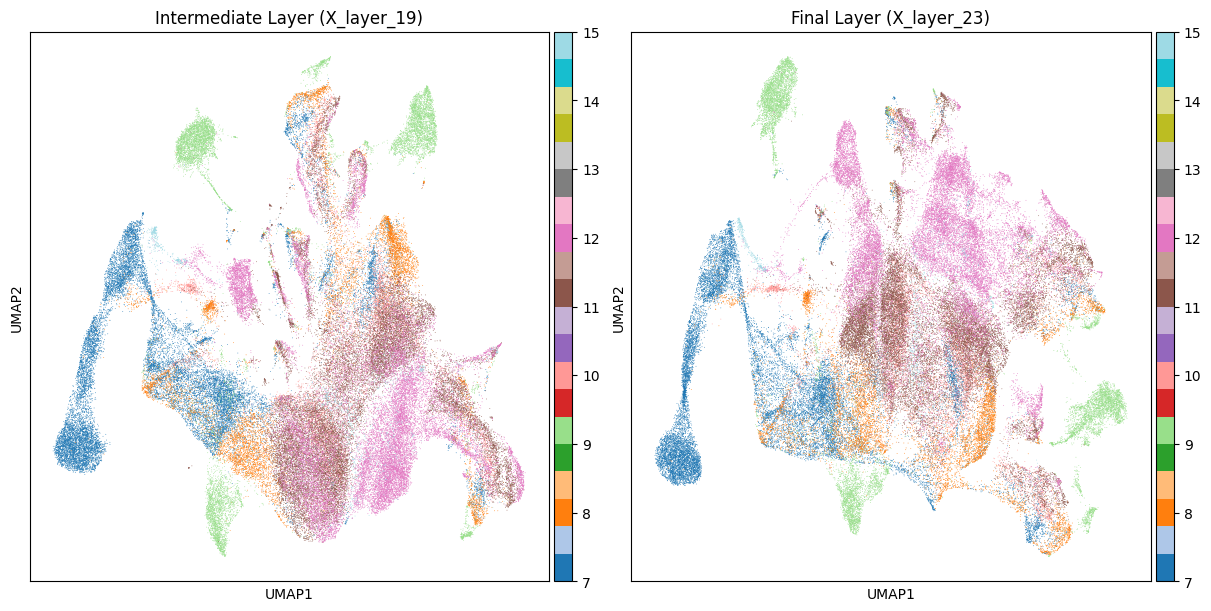

In [7]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

def plot_umap_layer_comparison(adata, metrics_df, final_layer='X_layer_23', color='week', n_neighbors=15, min_dist=0.3):
    """
    Confronta il miglior layer intermedio vs layer finale usando UMAP colorato per una variabile continua.
    
    Params:
    - adata: AnnData con embedding in .obsm
    - metrics_df: pd.DataFrame con colonne 'Layer' e 'Pseudotime_Corr'
    - final_layer: nome del layer finale (default 'X_layer_23')
    - color: variabile continua in adata.obs per colorare il plot (default 'week')
    - n_neighbors, min_dist: parametri per UMAP
    
    Restituisce la figura matplotlib con 2 pannelli (intermedio vs finale).
    """

    # 1. Trova miglior layer intermedio (escluso quello finale)
    df_filtered = metrics_df[metrics_df['Layer'] != final_layer]
    best_layer = df_filtered.loc[df_filtered['Pseudotime_Corr'].idxmax(), 'Layer']
    print(f"Miglior layer intermedio scelto: {best_layer}")
    
    # 2. Funzione per creare AnnData da embedding
    def make_embedding_adata(adata, embedding_key):
        return ad.AnnData(
            X=adata.obsm[embedding_key],
            obs=adata.obs.copy()
        )
    
    # 3. Funzione per calcolare UMAP
    def compute_umap(adata_emb):
        sc.pp.neighbors(adata_emb, n_neighbors=n_neighbors)
        sc.tl.umap(adata_emb, min_dist=min_dist)
    
    # 4. Crea AnnData temporanei
    adata_mid = make_embedding_adata(adata, best_layer)
    adata_final = make_embedding_adata(adata, final_layer)
    
    # 5. Calcola UMAP indipendenti
    compute_umap(adata_mid)
    compute_umap(adata_final)
    
    # 6. Plot multipannello
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    
    # Trova limiti colore comuni per stessa scala
    vmin = min(adata_mid.obs[color].min(), adata_final.obs[color].min())
    vmax = max(adata_mid.obs[color].max(), adata_final.obs[color].max())

    cmap = 'tab20'
    vmin = None
    vmax = None
    
    
    # Plot layer intermedio
    sc.pl.umap(adata_mid, color=color, ax=axs[0], show=False,
               color_map=cmap, vmin=vmin, vmax=vmax, title=f'Intermediate Layer ({best_layer})')
    
    # Plot layer finale
    sc.pl.umap(adata_final, color=color, ax=axs[1], show=False,
               color_map=cmap, vmin=vmin, vmax=vmax, title=f'Final Layer ({final_layer})')
    
    plt.show()
    return fig

fig = plot_umap_layer_comparison(adata, results, final_layer='X_layer_23', color='week')

In [10]:
# load mtx 
import scanpy as sc
import anndata as ad
import pandas as pd

adata = sc.read_mtx('/data2/home/vcivale/scfm-layer-analysis-refactored/Fetal_12_1_matrix.mtx')

In [12]:
adata.obs

""
0
1
2
3
4
...
36596
36597
36598
36599
